# Clustering by workplace mental health culture

Grouping respondents purely by how they described their workplace's
mental health culture (benefits, care options, how easy it is to take
leave, whether coworkers/supervisors feel safe to talk to), not by
`work_interfere` or `treatment`, then checking real treatment-seeking
rate per cluster afterward.

In [1]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_pickle('cleaned_mhealth.pkl')

culture_cols = ['benefits', 'care_options', 'wellness_program', 'seek_help', 'anonymity',
                 'leave', 'mental_health_consequence', 'phys_health_consequence',
                 'coworkers', 'supervisor', 'mental_health_interview', 'phys_health_interview',
                 'mental_vs_physical', 'obs_consequence']

X = pd.get_dummies(df[culture_cols])
X.shape

(992, 43)

In [2]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, adjusted_rand_score

pca = PCA(n_components = 10, random_state = 42)
X_pca = pca.fit_transform(X)
print(f'10 components explain {pca.explained_variance_ratio_.sum():.1%} of variance')

10 components explain 64.9% of variance


In [3]:
K = 4
kmeans = KMeans(n_clusters = K, n_init = 10, random_state = 42)
kmeans_labels = kmeans.fit_predict(X_pca)

gmm = GaussianMixture(n_components = K, random_state = 42, n_init = 3)
gmm_labels = gmm.fit_predict(X_pca)

print('KMeans silhouette:', silhouette_score(X_pca, kmeans_labels))
print('KMeans vs GMM agreement (ARI):', adjusted_rand_score(kmeans_labels, gmm_labels))

KMeans silhouette: 0.13915619811033897
KMeans vs GMM agreement (ARI): 0.36034376485709824


In [4]:
profile = pd.DataFrame({
    'cluster': kmeans_labels,
    'treatment': (df.treatment == 'Yes').astype(int).values,
    'work_interfere_often_or_sometimes': df.work_interfere.isin(['Often', 'Sometimes']).astype(int).values,
})
cluster_summary = profile.groupby('cluster').agg(
    n = ('treatment', 'size'),
    treatment_rate = ('treatment', 'mean'),
    high_interference_rate = ('work_interfere_often_or_sometimes', 'mean'),
).round(3)
cluster_summary

,n,treatment_rate,high_interference_rate
cluster,,,
0,225,0.551,0.596
1,259,0.579,0.556
2,303,0.657,0.680
3,205,0.766,0.595


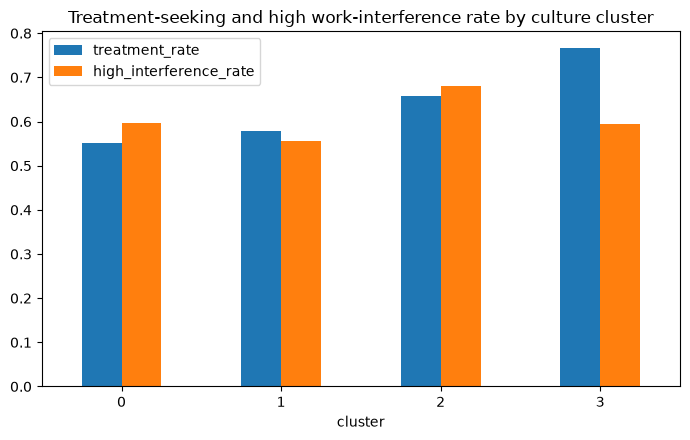

In [5]:
fig, ax = plt.subplots(figsize = (7, 4.5))
cluster_summary[['treatment_rate', 'high_interference_rate']].plot.bar(ax = ax)
ax.set_title('Treatment-seeking and high work-interference rate by culture cluster')
plt.xticks(rotation = 0)
plt.tight_layout()
plt.savefig('outputs/cluster_rates.png', dpi = 120)
plt.show()

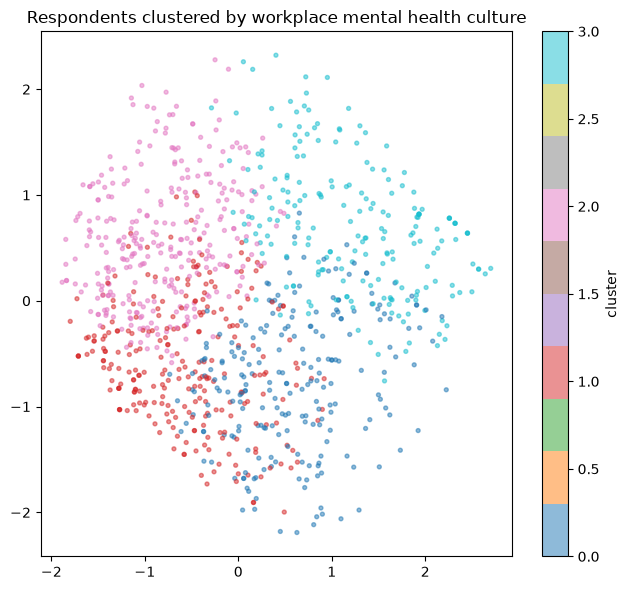

In [6]:
X_2d = PCA(n_components = 2, random_state = 42).fit_transform(X)
fig, ax = plt.subplots(figsize = (6.5, 6))
sc = ax.scatter(X_2d[:, 0], X_2d[:, 1], c = kmeans_labels, cmap = 'tab10', s = 8, alpha = 0.5)
ax.set_title('Respondents clustered by workplace mental health culture')
plt.colorbar(sc, ax = ax, label = 'cluster')
plt.tight_layout()
plt.savefig('outputs/cluster_pca.png', dpi = 120)
plt.show()

Silhouette (0.14) and KMeans/GMM agreement (ARI 0.36) are both modest,
these aren't 4 sharply distinct workplace cultures. Still, treatment
rate varies meaningfully across the 4 clusters, from 55.1% to 76.6%,
a real 21-point spread from workplace-culture answers alone, with no
knowledge of whether the respondent actually sought treatment.
`high_interference_rate` varies less (55.6% to 68.0%), a workplace's
described culture predicts whether someone seeks help somewhat better
than it predicts how much their work actually gets interfered with,
which lines up with the modest performance the supervised models in
notebook 03 got on `work_interfere` specifically.